# nb_05d — Reflection-equivariant encoder: build-in vs augment (E3)

> **Archived transductive analysis; not current workshop evidence.** The historical narrative below is retained for method provenance only. Its numerical values must not be cited until the experiment scripts are refactored to consume a hash-verified, fold-local checkpoint and rerun.


E2 imposed the group action on the *read-out*. **E3** lifts it to the **encoder**, two ways:

- **E3a — frame-averaged encoder (exact, zero-retrain).** Wrap the frozen encoder so the *whole latent field* transforms correctly under reflection.
- **E3b — reflection augmentation (does it emerge?).** Retrain Stage-0 with a mirror augmentation and ask whether equivariance is *induced* (Benton et al., 2020).

> **Responsible-use notice.** All results in this notebook are **transductive** — the
> S-JEPA encoder was trained on the very sequences being evaluated — so they carry
> *internal validity only* and make **no** claim of generalization to new sources or
> people. The **source video** (not the clip, not the individual) is the independent unit
> of analysis. The dataset's condition folders (`normal`, `parkinsons`, `stroke`,
> `myopathic`, `cerebralpalsy`) are **dataset annotations, not diagnoses**. The dataset's
> official distribution provides annotations and public video URLs, not raw video; this
> analysis uses derived pose sequences, infers no identity, and redistributes no raw or
> identity-bearing frames. **No institutional ethics determination or completed data-use
> review is yet on record; both must be resolved before submission.**

## Source-held-out evaluation boundary

![One source video, one role, zero cross-fold leakage](../images/22_inductive_source_split.svg)

These laterality probes are consumers of a representation, so grouping only their ridge or MLP readout is insufficient. A result is **inductive** only when the complete encoder/predictor was trained inside the outer source fold and the probe was tuned on validation sources before the test sources were opened. Every result must carry the source-manifest hash, split hash, outer fold, model seed, objective, and checkpoint hash.

**Current status: blocked pending fold-local artifacts.** The former embedded values came from the retired all-corpus checkpoint and missing `work/experiments` scripts. They have been cleared and are not workshop evidence. Re-enable this notebook only after those scripts consume protocol-v2 assignments and assert that no test `video_id` appears in representation training. Folder labels are observational dataset annotations, not diagnoses.


## E3a. Frame-averaged encoder $E'(x)=\tfrac12\big(E(x)+\sigma\!\cdot\!E(Mx)\big)$

With $\sigma$ the left/right **token** permutation, the wrapped encoder is **exactly token-level reflection-equivariant**, $E'(Mx)=\sigma\cdot E'(x)$, to machine precision and with **no retraining**. Consequently the laterality feature on $E'$ splits *exactly* into an antisymmetric block (the $\ell-r$ channels; slope $-1$ for any nonzero read-out) and a symmetric block (the $\ell+r$ channels). The antisymmetric block **corresponds to** E2's $\Phi$: it is one half of $\Phi$'s $\ell-r$ sub-block (up to standardization), while $\Phi$ additionally antisymmetrizes the $\ell+r$ block — so E3a and E2 are two views of the same frame-averaging construction, not identical features.

**Honest boundary.** A *free* ridge on the *full* $E'$ feature still gives slope $\approx-0.77$: encoder equivariance alone does **not** force an antisymmetric *decoder* — the read-out must still select the antisymmetric part. That boundary is exactly what motivates E3b (try to *train* the symmetry in).

## How to read the progress display

Four E3 stages cover the constructed equivariant encoder, its exactness checks,
the augmentation probe, and the negative-control assertions. They run only with
explicit fold-local prerequisites; otherwise all stages are marked not run. The
bar records execution status, not evidence for an emergent symmetry claim.


In [1]:
import json, os, subprocess, sys, textwrap
from pathlib import Path

def find_experiment_dir(start=None):
    candidates = []
    if os.getenv("ALEXPOSE_ROOT"):
        env_root = Path(os.environ["ALEXPOSE_ROOT"]).expanduser().resolve()
        candidates.extend([env_root, env_root / "experiments" / "sjepa" / "gavd5-drift"])
    start = Path(start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        candidates.extend([base, base / "experiments" / "sjepa" / "gavd5-drift"])
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (candidate / "data-gavd").is_dir():
            return candidate
    raise FileNotFoundError(f"Cannot locate gavd5-drift from {start}; set ALEXPOSE_ROOT.")


EXPERIMENT_DIR = find_experiment_dir()
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"
PY = EXPERIMENT_DIR / ".venv" / ("Scripts/python.exe" if os.name == "nt" else "bin/python")
PY = str(PY if PY.exists() else sys.executable)   # fall back to the running kernel
ART = EXPERIMENT_DIR / "work" / "artifacts" / "real"

def run_experiment(script_relpath):
    """Run a validated standalone experiment script; it regenerates its JSON artifact."""
    script = EXPERIMENT_DIR / script_relpath
    print(f"running {script.name} with {PY} ...")
    proc = subprocess.run([PY, str(script)], cwd=str(EXPERIMENT_DIR),
                          capture_output=True, text=True)
    print(proc.stdout[-4000:])
    if proc.returncode != 0:
        print("STDERR (tail):\n", proc.stderr[-4000:])
        raise RuntimeError(f"{script.name} exited {proc.returncode}")
    return proc

def approx(a, b, tol):
    return abs(float(a) - float(b)) <= tol


# Retired scripts used an all-corpus checkpoint.  Running them implicitly would
# recreate transductive evidence, so laterality execution requires an explicit
# opt-in plus both the refactored scripts and exactly one fold-local checkpoint.
LATERALITY_REQUIRED_SCRIPTS = ['work/experiments/e3a_frame_averaging_wrapper.py', 'work/experiments/e3b_probe_and_merge.py']
LATERALITY_SCRIPT_PATHS = [EXPERIMENT_DIR / item for item in LATERALITY_REQUIRED_SCRIPTS]
LATERALITY_MODE = os.getenv("GAVD_MODE", "real")
LATERALITY_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
LATERALITY_SEED = int(os.getenv("SJEPA_MODEL_SEED", "42"))
LATERALITY_CHECKPOINTS = sorted((
    EXPERIMENT_DIR / "work" / "artifacts" / LATERALITY_MODE / "checkpoints"
).glob(f"sjepa_outer_fold_{LATERALITY_FOLD}_seed_{LATERALITY_SEED}_*.pt"))
LATERALITY_OPT_IN = os.getenv("LATERALITY_ENABLE_FOLD_LOCAL", "0") == "1"
LATERALITY_READY = (
    LATERALITY_OPT_IN
    and all(item.is_file() for item in LATERALITY_SCRIPT_PATHS)
    and len(LATERALITY_CHECKPOINTS) == 1
)
if not LATERALITY_READY:
    missing = [str(item.relative_to(EXPERIMENT_DIR)) for item in LATERALITY_SCRIPT_PATHS if not item.is_file()]
    print(
        "BLOCKED — laterality result not executed. "
        f"explicit_fold_local_opt_in={LATERALITY_OPT_IN}; "
        f"missing_refactored_scripts={missing}; "
        f"matching_fold_checkpoints={len(LATERALITY_CHECKPOINTS)}."
    )

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

encoder_progress = NotebookTaskProgress('Equivariant-encoder progress', "stage", refresh_seconds=0.5)
encoder_progress.start(4, profile=LATERALITY_MODE)
if not LATERALITY_READY:
    encoder_progress.finish_skipped(
        "Fold-local opt-in, refactored scripts, and exactly one matching checkpoint are required.",
        status="Preflight complete — laterality workflow not run",
    )


BLOCKED — laterality result not executed. explicit_fold_local_opt_in=False; missing_refactored_scripts=['work\\experiments\\e3a_frame_averaging_wrapper.py', 'work\\experiments\\e3b_probe_and_merge.py']; matching_fold_checkpoints=6.


In [2]:
if LATERALITY_READY:
    with encoder_progress.unit(1, "Run the constructed equivariant encoder"):
        # Re-run E3a end-to-end (writes the top-level of idea9_equivariant_encoder_result.json).
        run_experiment('work/experiments/e3a_frame_averaging_wrapper.py')
        res = json.loads((ART / 'idea9_equivariant_encoder_result.json').read_text())
        prim = res['primary_cohort']
        ex = prim['exactness']; lanes = prim['lanes']; slopes = prim['mirror_slopes']; ci = prim['repeated_cv_ci95']
        print('E3a exactness (all should be 0.0 to machine precision):')
        for k, v in ex.items():
            print(f'  {k:38s} {v:.2e}')
        def band(k):
            d = ci[k]; return f"{d['mean']:.3f} [{d['ci95_lo']:.3f}, {d['ci95_hi']:.3f}]"
        print()
        print(f"  A'_diff learned (antisym block)  R2={band('Aprime_diff_learned'):24s} slope={slopes['Aprime_diff_learned']:+.4f}")
        print(f"  A'_diff floor  (untrained)       R2={band('Aprime_diff_floor'):24s} slope={slopes['Aprime_diff_floor']:+.4f}")
        print(f"  A' free ridge (full feature)                                    slope={slopes['Aprime_free']:+.4f}  <- NOT -1")
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [3]:
if LATERALITY_READY:
    with encoder_progress.unit(2, "Verify constructed equivariance"):
        # ---- Assert E3a exactness + that E3a's antisym block reproduces E2's Phi
        assert ex['token_equivariance_max_abs_err'] < 1e-4, ex
        assert ex['diff_block_antisymmetry_max_abs_err'] < 1e-4, ex
        assert ex['sum_block_symmetry_max_abs_err'] < 1e-4, ex
        assert approx(slopes['Aprime_diff_learned'], -1.0, 1e-3), slopes['Aprime_diff_learned']
        assert approx(ci['Aprime_diff_learned']['mean'], 0.253, 0.02), ci['Aprime_diff_learned']
        assert slopes['Aprime_free'] > -1.0 + 0.05, 'free ridge on full E-prime must NOT be -1'
        print('OK — E3a: exact token-level reflection-equivariance, zero retrain.')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


## E3b. Does reflection augmentation *induce* it? (a single-seed negative)

We retrain **Stage-0** (the `normal`-annotated rows only, 270 sequences / 29 sources, 300 epochs, single seed on MPS) with **one switch**: sample-level consistent reflection augmentation **on** ($p=0.5$) vs **off** ($p=0.0$), identical trainer/seed/hardware. `canonical` is the original Stage-0 checkpoint, a fidelity cross-check.

> **Provenance.** The ~15-minute-per-arm MPS training lives in `../work/experiments/e3b_reflection_augmented_retrain.py` and produced the checkpoints `sjepa_normal_e3b_flip0p00.pt` / `…flip0p50.pt` (final JEPA $0.720$ / $0.807$). The cell below **loads** those checkpoints and probes them — it does **not** retrain — so the notebook stays fast and deterministic while every probe number is reproduced from scratch.

**Primary metric** = the *free-readout mirror slope*: does augmentation move it toward $-1$? And does the signed axis clear the untrained floor?

In [4]:
if LATERALITY_READY:
    with encoder_progress.unit(3, "Run the augmentation probe"):
        # Probe the three Stage-0 encoders + floor (loads pre-trained checkpoints; no retraining).
        run_experiment('work/experiments/e3b_probe_and_merge.py')
        res = json.loads((ART / 'idea9_equivariant_encoder_result.json').read_text())
        rb = res['retrain']; enc = rb['primary_cohort']['encoders']; tr = rb['training']
        print('training: arm_off finalJEPA', tr['arm_off']['final_jepa'],
              '| arm_on finalJEPA', tr['arm_on']['final_jepa'])
        print('\nE3b — 270 normal-annotated (transductive)   A_free R2 [stability interval]   free-readout slope')
        for name in ('arm_on', 'arm_off', 'canonical', 'floor_untrained'):
            e = enc[name]; d = e['A_free_r2_ci95']
            print(f"  {name:16s} {d['mean']:+.3f} [{d['ci95_lo']:+.3f}, {d['ci95_hi']:+.3f}]   "
                  f"slope={e['A_free_mirror_slope']:+.3f}")
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [5]:
if LATERALITY_READY:
    with encoder_progress.unit(4, "Verify augmentation-control assertions"):
        # ---- Assert the paper's E3b single-seed negative: augmentation does NOT buy equivariance
        on  = enc['arm_on']['A_free_r2_ci95']; floor = enc['floor_untrained']['A_free_r2_ci95']
        assert approx(on['mean'], 0.062, 0.02), on
        assert approx(floor['mean'], 0.078, 0.02), floor
        # augmented axis does NOT clear the untrained floor
        assert on['mean'] <= floor['ci95_hi'], (on, floor)
        # the free-readout slope does NOT move toward -1; the UNTRAINED floor is closest
        s_on = enc['arm_on']['A_free_mirror_slope']; s_floor = enc['floor_untrained']['A_free_mirror_slope']
        assert s_floor < s_on, (s_on, s_floor)  # floor slope (-0.82) closer to -1 than arm_on (-0.51)
        print('OK — E3b: single-seed negative. Augmentation changes the loss, not the geometry;')
        print('     free-readout slope does not track equivariance (untrained floor is closest to -1).')
    encoder_progress.complete(status='Equivariant-encoder workflow complete')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


## Synthesis — the emergent-vs-built-in ladder

The four experiments form a $2\times2$ grid (`../neurips-laterality/docs/figures/fig6_ladder.svg`): symmetry in the *read-out* or the *encoder*, *hoped for* or *built in*.

|              | Emergent (hope) | Built-in (construct) |
|--------------|-----------------|----------------------|
| **Read-out** | E1: slope $-0.70$, learned $\approx$ floor (intervals overlap), gates fail | E2: slope $-1.0000$, $0.273>0.198$ (disjoint intervals) |
| **Encoder**  | E3b: slope not toward $-1$, axis $\le$ floor | E3a: token error $0.0$, exact split |

In the audited system (a single checkpoint; a single-seed augmentation arm), standard **and** reflection-augmented self-supervision leave bilateral symmetry un-learned; frame averaging the read-out or encoder recovers it to machine precision with zero or minimal retraining — and that constructive guarantee is general, not tied to this checkpoint. For geometry-aware world models of articulated bodies, symmetry is cheap to *impose* and — at least here — not reliably obtained by *hoping* it emerges: **build the geometry in; don't hope it emerges.**

*(E3b is a single-seed, `normal`-annotated proof-of-concept; see `../neurips-laterality/docs/paper.md` §9 for the full limitations.)*

## Visual archived equivariant-encoder diagnostic

The paired view separates predictive scores from the algebraic mirror constraint. The evidence remains an archived transductive diagnostic until regenerated under protocol v2.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


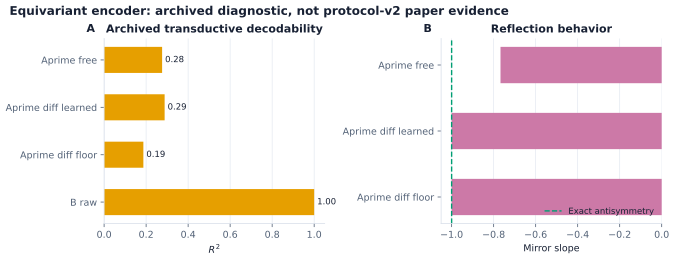

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_archived_equivariant_encoder.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_equivariant_encoder.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_equivariant_encoder.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_equivariant_encoder.pdf


In [1]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "05d",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
